In [3]:
from models.base_model import TimeSeriesRegressionModel
from utils.data import CMAPSSDataset

In [4]:
data = CMAPSSDataset(clip_rul=False).load()

In [5]:
common_config = {
    "df": data,
    "target_column": "RUL",
    "group_column": "unique_motor_id",
    "time_column": "cycle",
    "test_group_count": 10,
    "group_selection": "random",
    "columns_to_drop": ["dataset", "unit_number"],
    "random_state": 42,
}

In [6]:
linear_model = TimeSeriesRegressionModel(
    **common_config,
    model_name="linear",
)

linear_metrics = linear_model.train()
print(linear_metrics)

Training series: 699 | Testing series: 10
Training rows: 158,108 | Testing rows: 2,251
{'train': {'MAE': 38.55238652049863, 'RMSE': 51.23548543266969, 'R2': 0.6207426173468608, 'MAPE': 77.36916240963403, 'Bias': 8.228180872669293e-14}, 'test': {'MAE': 57.7297689256178, 'RMSE': 74.47198049159745, 'R2': 0.4874002183606567, 'MAPE': 93.2499009021711, 'Bias': 22.11252197265312}}


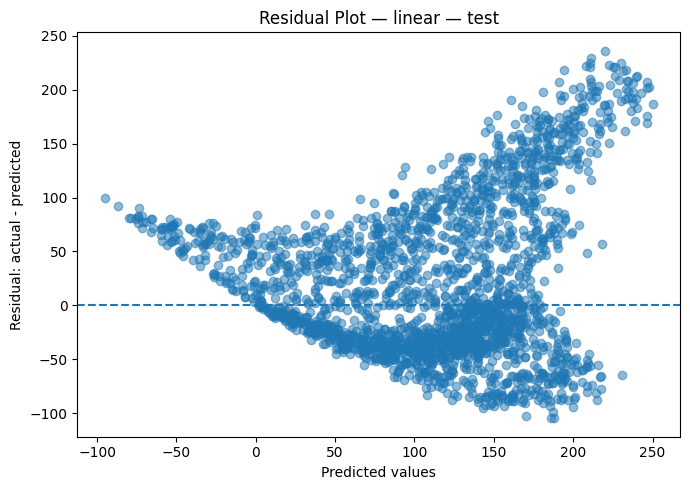

In [7]:
linear_model.plot_residuals()

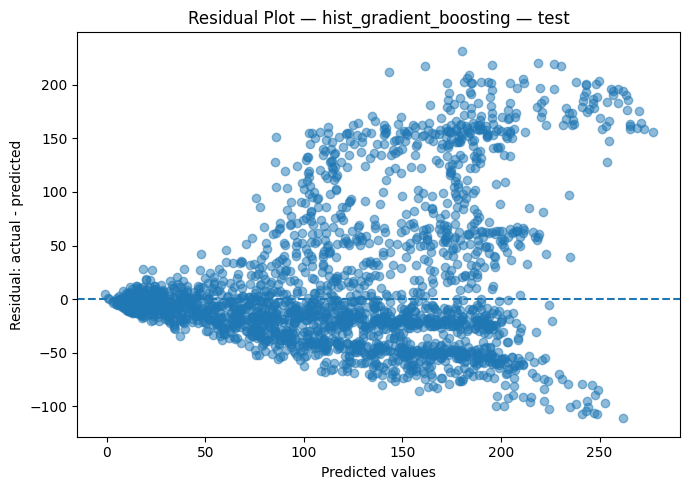

In [8]:

boosting_model2.plot_residuals()

In [18]:
ridge_model = TimeSeriesRegressionModel(
    **common_config,
    model_name="ridge",
    model_params={
        "alpha": 1.0,
    },
)

ridge_metrics = ridge_model.train()
print(ridge_metrics)

Training series: 699 | Testing series: 10
Training rows: 158,108 | Testing rows: 2,251
{'train': {'MAE': 38.80703649326309, 'RMSE': 51.58917316609239, 'R2': 0.6154883809675447, 'MAPE': 79.98717023397842, 'Bias': 1.4104795511594734e-13}, 'test': {'MAE': 56.06021005026718, 'RMSE': 73.39943125864625, 'R2': 0.5020588714025715, 'MAPE': 91.89131055611233, 'Bias': 20.271826720487823}}


In [19]:
ridge_model_10 = TimeSeriesRegressionModel(
    **common_config,
    model_name="ridge",
    model_params={
        "alpha": 10.0,
    },
)

print(ridge_model_10.train())

Training series: 699 | Testing series: 10
Training rows: 158,108 | Testing rows: 2,251


{'train': {'MAE': 38.96192769185942, 'RMSE': 51.81645232404077, 'R2': 0.6120929405763184, 'MAPE': 79.86430217529966, 'Bias': 5.295625916792052e-14}, 'test': {'MAE': 56.28974957462633, 'RMSE': 73.66116087387596, 'R2': 0.49850139697581086, 'MAPE': 92.6048039885235, 'Bias': 20.058611098971532}}


In [20]:
elastic_net_model = TimeSeriesRegressionModel(
    **common_config,
    model_name="elastic_net",
    model_params={
        "alpha": 0.01,
        "l1_ratio": 0.5,
        "max_iter": 20_000,
    },
)

elastic_net_metrics = elastic_net_model.train()
print(elastic_net_metrics)

Training series: 699 | Testing series: 10
Training rows: 158,108 | Testing rows: 2,251
{'train': {'MAE': 41.56763204023204, 'RMSE': 55.27880269461198, 'R2': 0.5585214690155238, 'MAPE': 86.2605827889814, 'Bias': 1.4726050778826473e-14}, 'test': {'MAE': 66.9224751061123, 'RMSE': 83.47010814111117, 'R2': 0.35604641978925144, 'MAPE': 115.80904061846805, 'Bias': 20.375900003082794}}


In [ ]:
random_forest_model = TimeSeriesRegressionModel(
    **common_config,
    model_name="random_forest",
    model_params={
        "n_estimators": 300,
        "max_depth": None,
        "min_samples_leaf": 2,
        "max_features": "sqrt",
        "n_jobs": -1,
    },
)

random_forest_metrics = random_forest_model.train()
print(random_forest_metrics)

Training series: 699 | Testing series: 10
Training rows: 158,108 | Testing rows: 2,251


In [ ]:
extra_trees_model = TimeSeriesRegressionModel(
    **common_config,
    model_name="extra_trees",
    model_params={
        "n_estimators": 300,
        "max_depth": None,
        "min_samples_leaf": 2,
        "max_features": 1.0,
        "n_jobs": -1,
    },
)

extra_trees_metrics = extra_trees_model.train()
print(extra_trees_metrics)

In [ ]:
boosting_model = TimeSeriesRegressionModel(
    **common_config,
    model_name="hist_gradient_boosting",
    model_params={
        "learning_rate": 0.08,
        "max_iter": 300,
        "max_leaf_nodes": 31,
        "max_depth": None,
        "min_samples_leaf": 20,
        "l2_regularization": 1.0,
    },
)

boosting_metrics = boosting_model.train()
print(boosting_metrics)

In [ ]:
boosting_regularized = TimeSeriesRegressionModel(
    **common_config,
    model_name="hist_gradient_boosting",
    model_params={
        "learning_rate": 0.04,
        "max_iter": 500,
        "max_leaf_nodes": 20,
        "max_depth": 8,
        "min_samples_leaf": 30,
        "l2_regularization": 5.0,
    },
)

print(boosting_regularized.train())

In [ ]:
svr_model = TimeSeriesRegressionModel(
    **common_config,
    model_name="svr",
    model_params={
        "kernel": "rbf",
        "C": 10.0,
        "epsilon": 0.1,
        "gamma": "scale",
    },
)

svr_metrics = svr_model.train()
print(svr_metrics)

Train automatically

In [ ]:
model_configs = {
    "linear": {},
    "ridge": {
        "alpha": 1.0,
    },
    "elastic_net": {
        "alpha": 0.01,
        "l1_ratio": 0.5,
        "max_iter": 20_000,
    },
    "random_forest": {
        "n_estimators": 300,
        "min_samples_leaf": 2,
        "max_features": "sqrt",
        "n_jobs": -1,
    },
    "extra_trees": {
        "n_estimators": 300,
        "min_samples_leaf": 2,
        "max_features": 1.0,
        "n_jobs": -1,
    },
    "hist_gradient_boosting": {
        "learning_rate": 0.08,
        "max_iter": 300,
        "max_leaf_nodes": 31,
        "min_samples_leaf": 20,
        "l2_regularization": 1.0,
    },
    "svr": {
        "kernel": "rbf",
        "C": 10.0,
        "epsilon": 0.1,
        "gamma": "scale",
    },
}

In [ ]:
trained_models = {}
comparison_rows = []

for model_name, model_params in model_configs.items():
    print(f"\nTraining {model_name}...")

    experiment = TimeSeriesRegressionModel(
        **common_config,
        model_name=model_name,
        model_params=model_params,
    )

    metrics = experiment.train()

    trained_models[model_name] = experiment

    comparison_rows.append({
        "model": model_name,
        "train_MAE": metrics["train"]["MAE"],
        "test_MAE": metrics["test"]["MAE"],
        "train_RMSE": metrics["train"]["RMSE"],
        "test_RMSE": metrics["test"]["RMSE"],
        "train_R2": metrics["train"]["R2"],
        "test_R2": metrics["test"]["R2"],
        "test_Bias": metrics["test"]["Bias"],
    })

In [ ]:
comparison_df = (
    pd.DataFrame(comparison_rows)
    .sort_values("test_RMSE")
    .reset_index(drop=True)
)

print(comparison_df)